<a href="https://colab.research.google.com/github/JohnMaleek/DevOps-Mini-Projects-Automation/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exercise 1

Use the Mean square error function from the scikit-learn package to measure the loss of the house price predictor model. (1p)

In [37]:
#import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error #important one

#dataset
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
Y = pd.DataFrame(housing.target)

#Setup about Spliting the data train & test
(x_train, x_test, y_train, y_test) = train_test_split(X, Y, test_size=0.2, random_state=2021)


#create my own model
lModel = LinearRegression()
lModel.fit(x_train, y_train) # ===>> in this step i tried to train it


#this could be the last step which we can generate predictions
y_pred = lModel.predict(x_test)

#From scikit-learn package
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Square Error  predictor model: {mse}")



Mean Square Error  predictor model: 0.5198679461616839


### Exercise 2

Use the Ridge regression ($\alpha$=0.001) model on the California housing dataset and plot its result. (1p)

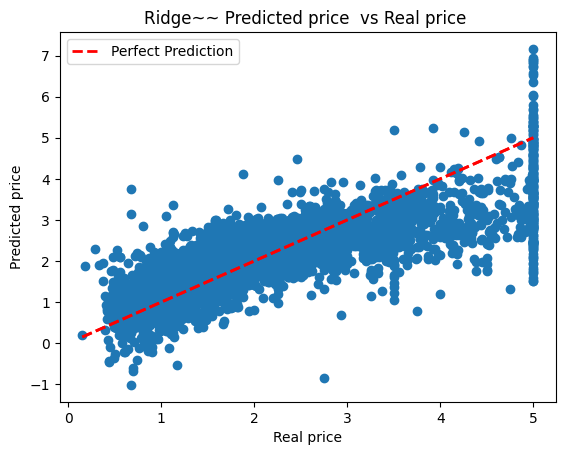

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge #important one

#loading dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
Y = pd.DataFrame(housing.target)


(x_train, x_test, y_train, y_test) = train_test_split(X, Y, test_size=0.2, random_state=2021)



#this is ~~OPTIONAL~~ to refer to the line in the mid of the graph
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.legend()


def visulaize_prediction(y, y_pred):  #these code about plt and visualization #---
    plt.scatter(y, y_pred)
    plt.xlabel("Real price")
    plt.ylabel(r"Predicted price")
    plt.title(r"Ridge~~ Predicted price  vs Real price ")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # this is ~~~OPTIONAL~~ mid line in the graph to refer to good prediction
    plt.show()                      #-----


#Use the Ridge regression (alpha=0.001) model
ridge_reg = Ridge(alpha=0.001)
ridge_reg.fit(x_train, y_train)





# 5. Generate predictions and plot the results
y_pred_ridge = ridge_reg.predict(x_test)
visulaize_prediction(y_test, y_pred_ridge)

### Exercise 3

Use the Lasso regression ($\alpha$=0.0001) model on the California housing dataset and plot its result. (1p)

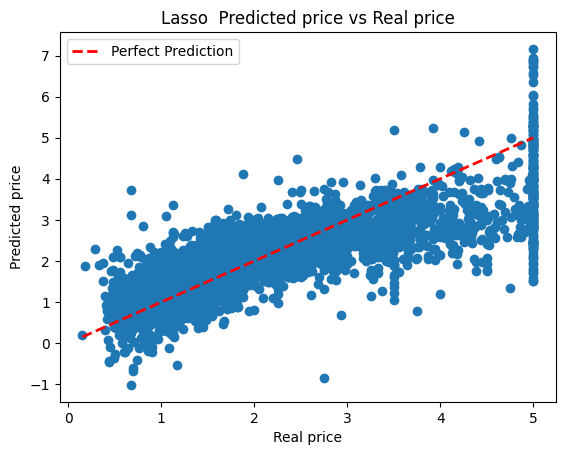

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso # Important Package

# Loading dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
Y = pd.DataFrame(housing.target)

# Splitting data (using the same random state as the notebook)
(x_train, x_test, y_train, y_test) = train_test_split(X, Y, test_size=0.2, random_state=2021)

#these lines about plt and visualization #_____________--
def visulaize_prediction(y, y_pred):
    plt.scatter(y, y_pred)
    plt.xlabel("Real price")
    plt.ylabel(r"Predicted price")
    plt.title(r"Lasso  Predicted price vs Real price")

    # Mid-line to refer to good prediction
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
    plt.legend()
    plt.show()
#______________________


# 1. Use the Lasso regression
lasso_reg = Lasso(alpha=0.0001)
lasso_reg.fit(x_train, y_train)

# 2. Generate predictions and plot the results
y_pred_lasso = lasso_reg.predict(x_test)
visulaize_prediction(y_test, y_pred_lasso)


### Exercise 4

Add higher polynomian features to the polynomial regression example (from 4 to 9). Visualize all regression curves in the same graph with different color. (1p)

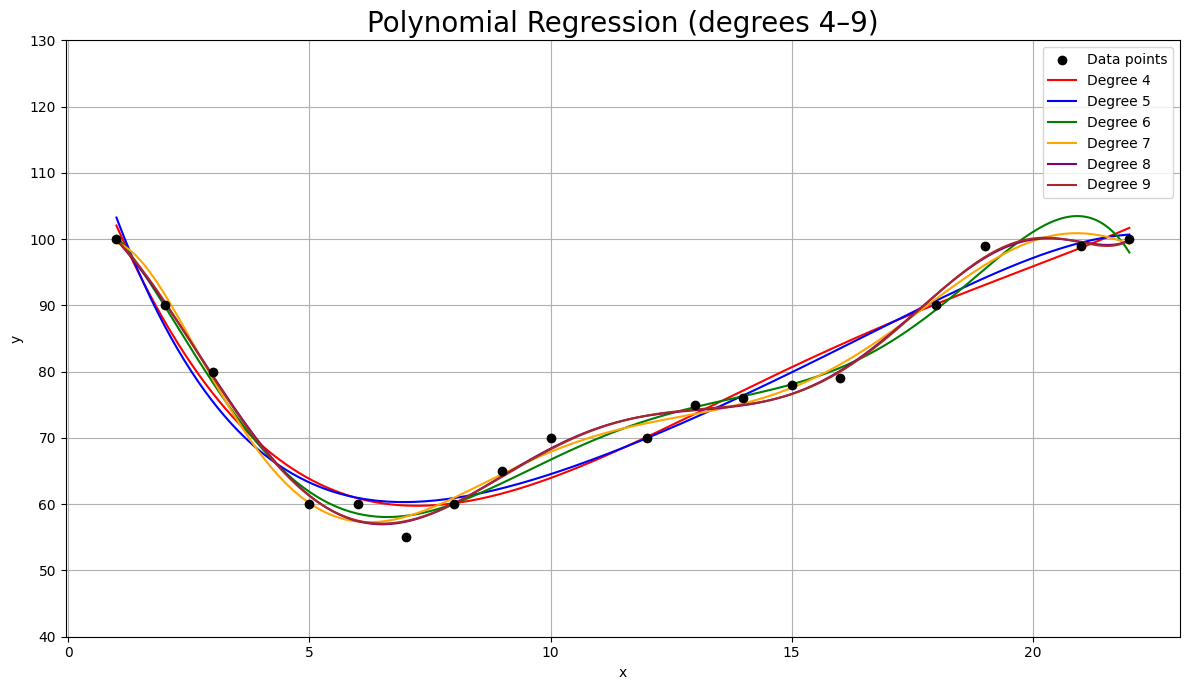

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

x = np.asarray([1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22])
y = np.asarray([100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100])  #I used the same data which was used in notebook

x = x.reshape(-1, 1) #very imp cuz sklearn packge required the input to be in this shape [number_of_samples , number_of_features]


#There are 2 ways to specifing the colours of the line the first one which i used here this code that i used all colors that i need it to display
#another way is to make model choosing its color by writing  plt.plot(x, y_pred, label=f'Degree {degree}') without mentiong color=color in that line

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
degrees = range(4, 10)  # 4 to 9

plt.figure(figsize=(12, 7))
plt.title("Polynomial Regression (degrees 4–9)", size=20)
plt.xlabel("x")
plt.ylabel("y")
plt.scatter(x, y, color='black', zorder=5, label='Data points')


#this loop makes each degree pass through each parallel colour
for degree, color in zip(degrees, colors):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    features = poly.fit_transform(x)
    features_plot = poly.transform(x_plot)

    model = LinearRegression()
    model.fit(features, y)
    y_pred = model.predict(features_plot)

    plt.plot(x_plot, y_pred, color=color, label=f'Degree {degree}')

plt.legend()
plt.ylim(40, 130)
plt.tight_layout()


plt.grid(True) #optional
plt.show()
